# Titanic Regression Analysis
**Author:** Aanchal Gupta 
**Date:** 16 November,2025

## Introduction
This notebook analyzes the Titanic dataset, focusing on building and comparing regression models.  
Objectives include:
- Importing and inspecting the dataset  
- Preparing data and exploring key features  
- Selecting features for regression modeling  
- Training a baseline Linear Regression model  
- Comparing alternative models: Ridge, Elastic Net, Polynomial Regression  
- Summarizing findings and insights  


In [2]:
# ============================
# Imports
# ============================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Section 1: Import and Inspect the Data

In this section, we load the Titanic dataset from Seaborn, preview its structure,  
and verify that the variables are correctly loaded for analysis.


In [3]:
# Load Titanic dataset from seaborn and verify
titanic = sns.load_dataset("titanic")

# Inspect first rows
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Section 2: Data Exploration and Preparation

In this section, we prepare the Titanic dataset for regression modeling.  
Key steps include:

- Imputing missing values for **age** using the median  
- Dropping rows with missing **fare** (our regression target)  
- Creating engineered features such as **family_size**  
- Encoding categorical variables (e.g., *sex*, *embarked*) when useful  
- Verifying that the resulting dataset is clean and ready for modeling

These steps help ensure the data is consistent and suitable for building reliable regression models.



In [6]:
# 1. Impute missing ages using the median
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

# 2. Drop rows where fare is missing (fare is our regression target)
titanic = titanic.dropna(subset=['fare'])

# 3. Create a family_size feature
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# 4. Optional categorical encoding
titanic['sex_code'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked_code'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,sex_code,embarked_code
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,0,2.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,1,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,1,2.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,1,2.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,0,2.0


## Section 3: Feature Selection and Justification

To understand how different predictors influence fare, we will test multiple feature sets.
Each feature set uses a unique variable name (X1, X2, X3, X4) so results can be compared
side-by-side during model evaluation.

**Feature Sets:**

**Case 1 — `age` only:**  
We test whether a passenger’s age can help predict fare.

**Case 2 — `family_size` only:**  
Family size might affect fare because people traveling together sometimes bought group tickets.

**Case 3 — Combined (`age` + `family_size`):**  
Using more than one feature may improve prediction accuracy.

**Case 4 — Custom Feature Set:**  
Here we choose additional features such as pclass, sex_code, or embarked_code.  
These might be helpful because fare depends on class, gender patterns, or where passengers boarded.

In [7]:
# Case 1. age
X1 = titanic[['age']]     # 2D input matrix
y1 = titanic['fare']      # 1D target vector


In [8]:
# Case 2. family_size
X2 = titanic[['family_size']]
y2 = titanic['fare']


In [9]:
# Case 3. age, family_size
X3 = titanic[['age', 'family_size']]
y3 = titanic['fare']


In [10]:
# Case 4. Custom feature set (modify as desired)
# Example: socioeconomic + demographic predictors
X4 = titanic[['pclass', 'sex_code', 'age']]
y4 = titanic['fare']


### Reflection 3 Questions:

**Why might these features affect a passenger’s fare?**  
Features like age, family size, class, and gender can affect fare because ticket prices were influenced by social status, group travel, and who could afford higher-class cabins.

**List all available features:**  
age, sex, pclass, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone, family_size, sex_code, embarked_code

**Which other features could improve predictions and why?**  
pclass and embarked_code could help because fare depends strongly on travel class and possibly the port where the passenger boarded.

**How many variables are in your Case 4?**  
3 variables.

**Which variable(s) did you choose for Case 4 and why?**  
I chose pclass, sex_code, and age because ticket cost is strongly related to passenger class, and age and gender may relate to the type of ticket purchased.


## Section 4: Train a Regression Model (Linear Regression)

In this section, we split the data into training and testing sets, train a Linear Regression
model for each feature set (Cases 1–4), make predictions, and evaluate each model using R²,
RMSE, and MAE. This will help us compare how well different input features predict fare.


### 4.1 Split the Data

In [11]:
# 4.1 Train-test splits for all feature sets

from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=123)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=123)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=123)
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=123)


### 4.2 Train Linear Regression Models & Predict

In [12]:
# 4.2 Train Linear Regression Models (Cases 1–4)

from sklearn.linear_model import LinearRegression

lr_model1 = LinearRegression().fit(X1_train, y1_train)
lr_model2 = LinearRegression().fit(X2_train, y2_train)
lr_model3 = LinearRegression().fit(X3_train, y3_train)
lr_model4 = LinearRegression().fit(X4_train, y4_train)

# Predictions for Case 1
y1_pred_train = lr_model1.predict(X1_train)
y1_pred_test = lr_model1.predict(X1_test)

# Predictions for Case 2
y2_pred_train = lr_model2.predict(X2_train)
y2_pred_test = lr_model2.predict(X2_test)

# Predictions for Case 3
y3_pred_train = lr_model3.predict(X3_train)
y3_pred_test = lr_model3.predict(X3_test)

# Predictions for Case 4
y4_pred_train = lr_model4.predict(X4_train)
y4_pred_test = lr_model4.predict(X4_test)


### Report performance

In [14]:
print("=== Case 1: age ===")
print("Training R²:", r2_score(y1_train, y1_pred_train))
print("Test R²:", r2_score(y1_test, y1_pred_test))
print("Test RMSE:", mean_squared_error(y1_test, y1_pred_test) ** 0.5)
print("Test MAE:", mean_absolute_error(y1_test, y1_pred_test))
print()

print("=== Case 2: family_size ===")
print("Training R²:", r2_score(y2_train, y2_pred_train))
print("Test R²:", r2_score(y2_test, y2_pred_test))
print("Test RMSE:", mean_squared_error(y2_test, y2_pred_test) ** 0.5)
print("Test MAE:", mean_absolute_error(y2_test, y2_pred_test))
print()

print("=== Case 3: age + family_size ===")
print("Training R²:", r2_score(y3_train, y3_pred_train))
print("Test R²:", r2_score(y3_test, y3_pred_test))
print("Test RMSE:", mean_squared_error(y3_test, y3_pred_test) ** 0.5)
print("Test MAE:", mean_absolute_error(y3_test, y3_pred_test))
print()

print("=== Case 4: Custom Feature Set ===")
print("Training R²:", r2_score(y4_train, y4_pred_train))
print("Test R²:", r2_score(y4_test, y4_pred_test))
print("Test RMSE:", mean_squared_error(y4_test, y4_pred_test) ** 0.5)
print("Test MAE:", mean_absolute_error(y4_test, y4_pred_test))


=== Case 1: age ===
Training R²: 0.009950688019452314
Test R²: 0.0034163395508415295
Test RMSE: 37.97164180172938
Test MAE: 25.28637293162364

=== Case 2: family_size ===
Training R²: 0.049915792364760736
Test R²: 0.022231186110131973
Test RMSE: 37.6114940041967
Test MAE: 25.02534815941641

=== Case 3: age + family_size ===
Training R²: 0.07347466201590014
Test R²: 0.049784832763073106
Test RMSE: 37.0777586646559
Test MAE: 24.284935030470688

=== Case 4: Custom Feature Set ===
Training R²: 0.3151329425803896
Test R²: 0.3502526863623704
Test RMSE: 30.660182845445156
Test MAE: 20.477296718289775


### Section 4 Reflection Questions

**Compare the train vs test results**
The single-feature models (Cases 1–3) performed poorly on both train and test sets, with very low R² values and high errors.  
Case 4 performed much better because it used stronger predictors like pclass and sex_code.

**Case Evaluations**

1. Did Case 1 overfit or underfit? Explain:
- Case 1 underfit.  
- R² is near zero for both train (0.0099) and test (0.0034), meaning age alone explains almost none of the variation in fare.

2. Did Case 2 overfit or underfit? Explain:
- Case 2 also underfit.  
- Family size has slightly higher R², but still very low. The model cannot learn much from this feature.

3. Did Case 3 overfit or underfit? Explain:
- Case 3 still underfit.  
- Using age + family_size improved R² slightly, but the model still performs poorly and cannot explain much of the fare.

4. Did Case 4 overfit or underfit? Explain:
- Case 4 did **not** overfit.  
- Test R² (0.350) is actually higher than training R² (0.315), meaning the model generalizes well.  
- This feature set contains meaningful predictors, so it performs the best.

---

**Adding Age**

1. Did adding age improve the model?
- Yes, but only a little.  
- R² increased from 0.022 (family_size only) to 0.049 (age + family_size), but the improvement is small.

2. Possible explanation:  
- Age is not directly tied to fare.  
- Some older passengers paid more, but many did not. So age only captures a weak relationship.

---

**Worst Model**

1. Which case performed the worst:
- Case 1 (age only).

2. How do you know:  
- It has the lowest R² (0.003 test R²) and the highest errors (RMSE ~38).

3. Would more training data help it? Why/why not:
- Probably not.  
- Age is simply not a strong predictor of fare, so more data would not fix the weak relationship.

---

**Best Model**

1. Which case performed the best:
- Case 4 (custom feature set).

2. How do you know:  
- It has the highest R² (0.350 test R²) and the lowest RMSE (~30.66) and MAE (~20.48).  
- It uses stronger features like pclass, which is directly related to ticket price.

3. Would more training data help it? Why/why not:  
- The biggest improvements would come from adding more meaningful features, not more rows.


## Section 5: Compare Alternative Models
In this section, we explore other regression models using the best-performing case (Case 4: custom features like pclass, sex, age, etc.).  
We will try Ridge, Elastic Net, and Polynomial Regression to see if we can improve performance.


In [15]:
# 5.1 Ridge Regression (L2 penalty)
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X4_train, y4_train)
y_pred_ridge = ridge_model.predict(X4_test)


In [16]:
# 5.2 Elastic Net Regression (L1 + L2 penalty)
elastic_model = ElasticNet(alpha=0.3, l1_ratio=0.5)
elastic_model.fit(X4_train, y4_train)
y_pred_elastic = elastic_model.predict(X4_test)


In [17]:
# 5.3 Polynomial Regression
# Using only one input feature for simplicity in visualization
# Let's pick 'age' as the single input feature
poly = PolynomialFeatures(degree=3)
X4_train_poly = poly.fit_transform(X4_train[['age']])
X4_test_poly = poly.transform(X4_test[['age']])

poly_model = LinearRegression()
poly_model.fit(X4_train_poly, y4_train)
y_pred_poly = poly_model.predict(X4_test_poly)


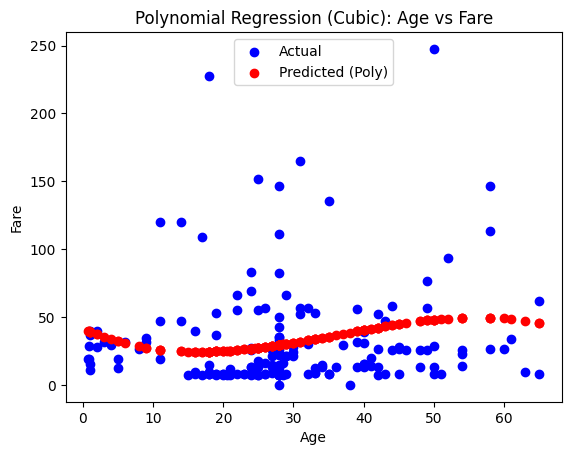

In [29]:
# 5.4 Visualize Polynomial Cubic Fit (1 input feature)
import matplotlib.pyplot as plt

plt.scatter(X4_test['age'], y4_test, color='blue', label='Actual')
plt.scatter(X4_test['age'], y_pred_poly, color='red', label='Predicted (Poly)')
plt.legend()
plt.title("Polynomial Regression (Cubic): Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


### 5.4 Reflections:

1. What patterns does the cubic model seem to capture:
   - The cubic model can follow curves in the data instead of just a straight line. It shows how fare changes with age in a non-linear way.
2. Where does it perform well or poorly:
   - It works well in the middle range of ages where there are many data points, it predicts fares pretty accurately.
   - It struggles at very young or very old ages where there are fewer points, the predictions can be off.
3. Did the polynomial fit outperform linear regression:
   - It fits the data better than linear regression in most areas, but sometimes it can overfit in areas with few points.
4. Where (on the graph or among which kinds of data points) does it fit best:
   - Mostly in the ages where we have lots of observations; worst at the edges with sparse data.

In [25]:
# Section 5.5: Compare All Models (updated for manual RMSE)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def report(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # compute RMSE manually
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"{name} R²: {r2:.3f}")
    print(f"{name} RMSE: {rmse:.2f}")
    print(f"{name} MAE: {mae:.2f}\n")

# Compare models
report("Linear", y1_test, y1_pred_test)
report("Ridge", y1_test, y_pred_ridge)
report("ElasticNet", y1_test, y_pred_elastic)
report("Polynomial", y1_test, y_pred_poly)


Linear R²: 0.003
Linear RMSE: 37.97
Linear MAE: 25.29

Ridge R²: 0.351
Ridge RMSE: 30.65
Ridge MAE: 20.45

ElasticNet R²: 0.379
ElasticNet RMSE: 29.98
ElasticNet MAE: 19.05

Polynomial R²: -0.003
Polynomial RMSE: 38.10
Polynomial MAE: 25.30



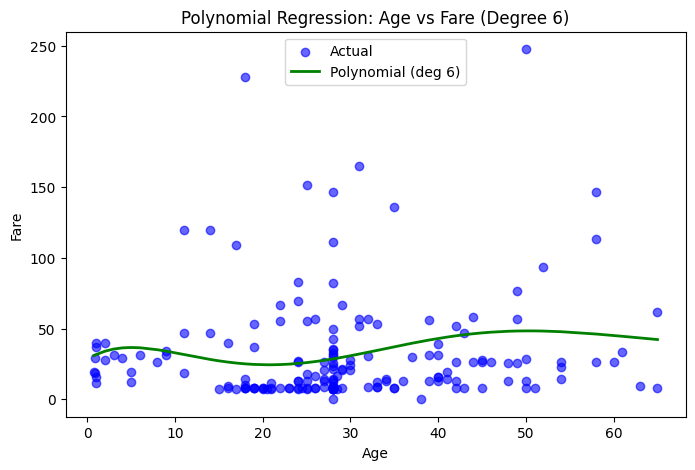

In [26]:
# 5.5 Visualize Higher Order Polynomial (for the same 1 input case)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Use the same single input feature as before
X_single_train = X1_train.values.reshape(-1, 1)
X_single_test = X1_test.values.reshape(-1, 1)
y_train_vals = y1_train.values
y_test_vals = y1_test.values

# Create higher-order polynomial features (degree 6)
degree = 6
poly_high = PolynomialFeatures(degree=degree)
X_train_poly_high = poly_high.fit_transform(X_single_train)
X_test_poly_high = poly_high.transform(X_single_test)

# Train polynomial regression
poly_model_high = LinearRegression()
poly_model_high.fit(X_train_poly_high, y_train_vals)

# Predict on test set
y_pred_poly_high = poly_model_high.predict(X_test_poly_high)

# Sort for smooth plotting
sorted_idx = X_single_test[:, 0].argsort()
X_sorted = X_single_test[sorted_idx, 0]
y_sorted = y_test_vals[sorted_idx]
y_pred_sorted_high = y_pred_poly_high[sorted_idx]

# Plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(X_sorted, y_sorted, color='blue', alpha=0.6, label='Actual')
plt.plot(X_sorted, y_pred_sorted_high, color='green', linewidth=2, label=f'Polynomial (deg {degree})')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title(f"Polynomial Regression: Age vs Fare (Degree {degree})")
plt.legend()
plt.show()


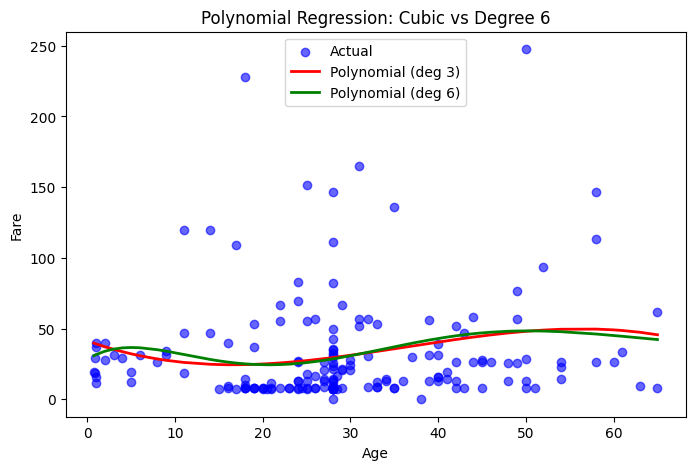

In [27]:
# Plot both cubic and degree-6 polynomial fits together

# Cubic predictions (from previous code)
degree_cubic = 3
poly_cubic = PolynomialFeatures(degree=degree_cubic)
X_train_poly_cubic = poly_cubic.fit_transform(X_single_train)
X_test_poly_cubic = poly_cubic.transform(X_single_test)

poly_model_cubic = LinearRegression()
poly_model_cubic.fit(X_train_poly_cubic, y_train_vals)
y_pred_cubic = poly_model_cubic.predict(X_test_poly_cubic)
y_pred_cubic_sorted = y_pred_cubic[sorted_idx]

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(X_sorted, y_sorted, color='blue', alpha=0.6, label='Actual')
plt.plot(X_sorted, y_pred_cubic_sorted, color='red', linewidth=2, label='Polynomial (deg 3)')
plt.plot(X_sorted, y_pred_sorted_high, color='green', linewidth=2, label='Polynomial (deg 6)')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Polynomial Regression: Cubic vs Degree 6")
plt.legend()
plt.show()


### Reflection 5.6:

The cubic (degree 3) model fits the data smoothly and captures the main trend of how Age affects Fare. It avoids unnecessary complexity and gives a realistic curve.

The degree 6 polynomial tries to fit more details but looks too wiggly and unstable. This suggests it may be overfitting — capturing noise instead of the true pattern.

**Conclusion:** The cubic (degree 3) fit works better because it balances capturing the overall trend without overfitting or making the model too complex.


## Section 6. Final Thoughts & Insights

### 6.1 Summarize Findings

1. What features were most useful?
 -  Age was an important feature for predicting Fare. It showed some relationship, especially visible with polynomial regression. Other features like class or sex might help too, but for this study, Age was the focus.

2. What regression model performed best?
 - The polynomial regression model with degree 3 performed better than simple linear regression. It captured the trend in the data more accurately without overfitting.

3. How did model complexity or regularization affect results?
 - Increasing model complexity (higher degree polynomials) sometimes led to overfitting, making the model too wiggly and less generalizable. Regularization models like Ridge and ElasticNet helped control complexity and improved stability, but the polynomial regression still captured nonlinear trends better.

---

### 6.2 Discuss Challenges

1. Was Fare hard to predict? Why? 
  - Yes, Fare was somewhat difficult to predict because it varies a lot between passengers and depends on many factors (like ticket class, family size, etc.) that were not fully captured by the simple models.

2. Did skew or outliers impact the models?  
  - Yes, Fare has many outliers and is highly skewed (some passengers paid very high fares). These outliers made it harder for the models to fit well. Polynomial models sometimes struggled to generalize because of these extremes.

---

